# Predicting house affiliation through Louvain community detection

**Research question:** Given a character's Louvain community membership, can we predict which *house* they belong to?

We answer this on three levels of granularity:

| Level | Label space | Method |
|---|---|---|
| **1** | All houses | Score Louvain on the full LCC against `primary_house` |
| **2** | Top-N largest houses | Restrict to characters in top-N houses, **re-run Louvain on that subgraph**, score |
| **3** | Top-K houses **per canonical region** (stratified, K=3) | Subgraph induced by stratified house set, re-run Louvain, score. Region is used only as the stratification axis — the prediction target is still house. |

**Headline metric:** *prediction accuracy* — for each Louvain community we predict its *dominant true label*, then check what fraction of characters' actual labels match the prediction. ARI / homogeneity / completeness reported alongside.

**Constraints (from session memory):**

* No CSV writes; no auto-saving plots. The Layer 0 (allegiance fallback) + Layer 1 (single-hop family inference) labelling logic from `community_vs_region.ipynb §2.5` is **re-implemented in this notebook** — the source CSV is read but never modified.
* Predictions are only scored against `primary_house` (i.e. `direct | secondary_allegiance | family` labels). Neighbour-majority predictions are NOT used as ground truth — that would be circular.

## 0. Setup

In [26]:
from collections import Counter, defaultdict
from community import community_louvain
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
import numpy as np
import pandas as pd
import random
import sys, os

from sklearn.metrics import (
    adjusted_rand_score,
    homogeneity_completeness_v_measure,
    normalized_mutual_info_score,
)

sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')) if '__file__' in globals() else '.')
from got_style import (
    apply_style, got_title, save_fig,
    PALETTE, diverging_colors, categorical_colors,
)
apply_style()

random.seed(42)
np.random.seed(42)


In [27]:
df = pd.read_csv('../csvs/characters_enriched_v3.csv').fillna('')
valid_ids = set(df['ID'])
name_by_id = dict(zip(df['ID'], df['name']))

edges = set()
for _, row in df.iterrows():
    src = row['ID']
    if not row['affiliated']:
        continue
    for tgt in row['affiliated'].split(';'):
        tgt = tgt.strip()
        if tgt and tgt != src and tgt in valid_ids:
            edges.add(frozenset({src, tgt}))

G = nx.Graph()
G.add_nodes_from(df['ID'])
G.add_edges_from(tuple(e) for e in edges)
LCC = G.subgraph(max(nx.connected_components(G), key=len)).copy()

print(f'Full graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges')
print(f'LCC:        {LCC.number_of_nodes()} nodes, {LCC.number_of_edges()} edges')

Full graph: 3690 nodes, 17169 edges
LCC:        3046 nodes, 17057 edges


## 1. Build house & region labels (Layer 0 + Layer 1, in-notebook)

Re-implementation of `community_vs_region.ipynb §2.5`. We do not modify the CSV; we just compute enriched labels in memory.

* **Layer 0 — allegiance walk**: pick the first `;`-separated allegiance entry that maps to a region.
* **Layer 1 — family inference**: for characters with no mappable allegiance, inherit from `father > mother > spouse` (single hop).

In [28]:
# House -> region mapping (canonical Westeros + non-geographic categories).
REGION_TO_HOUSES = {
    'North': ['House_Stark', 'House_Bolton', 'House_Karstark', 'House_Manderly',
        'House_Umber', 'House_Mormont', 'House_Glover', 'House_Reed', 'House_Ryswell',
        'House_Dustin', 'House_Cerwyn', 'House_Hornwood', 'House_Tallhart', 'House_Flint',
        'House_Cassel', 'House_Ashwood', 'House_Locke', 'House_Magnar', 'House_Forrester',
        'House_Stout', 'House_Slate', 'House_Norrey', 'House_Wull', 'House_Liddle',
        'House_Burley', 'House_Harclay', 'House_Knott'],
    'Iron_Islands': ['House_Greyjoy', 'House_Harlaw', 'House_Drumm', 'House_Goodbrother',
        'House_Saltcliffe', 'House_Stonehouse', 'House_Botley', 'House_Sparr', 'House_Wynch',
        'House_Codd', 'House_Blacktyde', 'House_Sunderly', 'House_Tawney', 'House_Volmark',
        'House_Merlyn', 'House_Ironmaker', 'House_Farwynd', 'House_Hoare'],
    'Riverlands': ['House_Tully', 'House_Frey', 'House_Bracken', 'House_Blackwood',
        'House_Mallister', 'House_Mooton', 'House_Vance', 'House_Whent', 'House_Piper',
        'House_Darry', 'House_Lothston', 'House_Charlton', 'House_Cox', 'House_Erenford',
        'House_Goodbrook', 'House_Haigh', 'House_Lychester', 'House_Mudd', 'House_Ryger',
        'House_Smallwood', 'House_Strong', 'House_Terrick', 'House_Paege', 'House_Roote',
        'House_Shawney', 'House_Wode', 'House_Nayland'],
    'Vale': ['House_Arryn', 'House_Royce', 'House_Corbray', 'House_Waynwood', 'House_Hunter',
        'House_Templeton', 'House_Redfort', 'House_Belmore', 'House_Coldwater', 'House_Egen',
        'House_Grafton', 'House_Hardyng', 'House_Hersy', 'House_Lipps', 'House_Lynderly',
        'House_Melcolm', 'House_Pryor', 'House_Sunderland', 'House_Tollett', 'House_Upcliff',
        'House_Borrell', 'House_Baelish', 'House_Shett', 'House_Crayne'],
    'Westerlands': ['House_Lannister', 'House_Marbrand', 'House_Crakehall', 'House_Lefford',
        'House_Brax', 'House_Banefort', 'House_Reyne', 'House_Tarbeck', 'House_Westerling',
        'House_Spicer', 'House_Payne', 'House_Clegane', 'House_Algood', 'House_Bettley',
        'House_Broom', 'House_Doggett', 'House_Estren', 'House_Falwell', 'House_Farman',
        'House_Foote', 'House_Garner', 'House_Hetherspoon', 'House_Jast', 'House_Kyndall',
        'House_Lannett', 'House_Lannister_of_Lannisport', 'House_Lorch', 'House_Lydden',
        'House_Moreland', 'House_Myatt', 'House_Parren', 'House_Peckledon', 'House_Plumm',
        'House_Prester', 'House_Ruttiger', 'House_Sarsfield', 'House_Serrett',
        'House_Stackspear', 'House_Swyft', 'House_Turnberry', 'House_Vikary', 'House_Yew',
        'House_Drox', 'House_Greenfield', 'House_Sarwyck'],
    'Reach': ['House_Tyrell', 'House_Hightower', 'House_Tarly', 'House_Florent',
        'House_Rowan', 'House_Redwyne', 'House_Oakheart', 'House_Fossoway', 'House_Ambrose',
        'House_Chester', 'House_Costayne', 'House_Beesbury', 'House_Caswell', 'House_Crane',
        'House_Cuy', 'House_Footly', 'House_Gardener', 'House_Graceford', 'House_Grimm',
        'House_Hewett', 'House_Inchfield', 'House_Kidwell', 'House_Leygood', 'House_Lowther',
        'House_Lyberr', 'House_Meadows', 'House_Merryweather', 'House_Mullendore',
        'House_Norcross', 'House_Norridge', 'House_Oldflowers', 'House_Orme', 'House_Osgrey',
        'House_Peake', 'House_Pommingham', 'House_Redding', 'House_Risley', 'House_Roxton',
        'House_Serry', 'House_Shermer', 'House_Sloane', 'House_Stackhouse', 'House_Uffering',
        'House_Varner', 'House_Vyrwel', 'House_Webber', 'House_Westbrook', 'House_Willum',
        'House_Wythers', 'House_Yelshire'],
    'Stormlands': ['House_Baratheon', 'House_Errol', 'House_Estermont', 'House_Penrose',
        'House_Tarth', 'House_Connington', 'House_Caron', 'House_Dondarrion', 'House_Selmy',
        'House_Swann', 'House_Wylde', 'House_Bolling', 'House_Buckler', 'House_Cafferen',
        'House_Carter', 'House_Fell', 'House_Grandison', 'House_Hasty', 'House_Herston',
        'House_Horpe', 'House_Kellington', 'House_Lonmouth', 'House_Mertyns', 'House_Morrigen',
        'House_Musgood', 'House_Peasebury', 'House_Rogers', 'House_Seaworth', 'House_Staedmon',
        'House_Trant', 'House_Wagstaff', 'House_Wensington', 'House_Whitehead', 'House_Toyne'],
    'Dorne': ['House_Martell', 'House_Yronwood', 'House_Dayne', 'House_Allyrion',
        'House_Blackmont', 'House_Fowler', 'House_Gargalen', 'House_Jordayne', 'House_Manwoody',
        'House_Qorgyle', 'House_Santagar', 'House_Toland', 'House_Uller', 'House_Vaith',
        'House_Wyl', 'House_Briar', 'House_Brook', 'House_Brownhill', 'House_Dalt',
        'House_Drinkwater', 'House_Holt', 'House_Hull', 'House_Lake', 'House_Ladybright',
        'House_Sand', 'House_Shell', 'House_Wells'],
    'Crownlands': ['House_Targaryen', 'House_Velaryon', 'House_Celtigar', 'House_Massey',
        'House_Rosby', 'House_Stokeworth', 'House_Buckwell', 'House_Crabb', 'House_Bar_Emmon',
        'House_Brune', 'House_Byrch', 'House_Chyttering', 'House_Cressey', 'House_Darklyn',
        'House_Edgerton', 'House_Farring', 'House_Gaunt', 'House_Hayford', 'House_Hogg',
        'House_Langward', 'House_Longwaters', 'House_Mallery', 'House_Pyle', 'House_Rambton',
        'House_Rollingford', 'House_Slynt', 'House_Staunton', 'House_Sunglass', 'House_Thorne',
        'House_Wendwater', 'House_Blackfyre', 'Blacks', 'House_Baratheon_of_Dragonstone',
        "House_Baratheon_of_King's_Landing"],
    'Beyond_the_Wall': ['Mance_Rayder', 'Stone_Crows', 'Free_Folk', 'Thenn',
        'Frozen_Shore', 'Hornfoot_clan'],
    'Essos': ['Drogo', 'Faceless_Men', 'House_of_Loraq', 'Unsullied', 'House_Rogare',
        'Volantis', 'Lys', 'Pentos', 'Braavos', 'Sons_of_the_Harpy', 'Yunkai', 'Astapor', 'Meereen'],
    'Order': ['Citadel', "Night's_Watch", 'Faith_of_the_Seven', 'Kingsguard', 'Maesters',
        'Sworn_Brothers'],
    'Sellsword': ['Golden_Company', 'Windblown', 'Second_Sons', 'Brave_Companions',
        'Stormcrows', 'Company_of_the_Cat', 'Long_Lances', "Maiden's_Men"],
    'Outlaw': ['Brotherhood_without_banners', "Smiling_Knight's_band"],
}
HOUSE_TO_REGION = {h: region for region, hs in REGION_TO_HOUSES.items() for h in hs}

CANONICAL_REGIONS = ['North', 'Iron_Islands', 'Riverlands', 'Vale', 'Westerlands',
                     'Reach', 'Stormlands', 'Dorne', 'Crownlands']
print(f'House->region entries: {len(HOUSE_TO_REGION)}')

House->region entries: 321


In [29]:
# §2.5-style enrichment: in-notebook only, never written back to CSV.
allegiance_lookup = dict(zip(df['ID'], df['allegiance']))
father_lookup    = dict(zip(df['ID'], df['father']))
mother_lookup    = dict(zip(df['ID'], df['mother']))
spouse_lookup    = dict(zip(df['ID'], df['spouse']))


def best_allegiance(s):
    if not s:
        return '', ''
    entries = [a.strip() for a in s.split(';') if a.strip()]
    for i, h in enumerate(entries):
        if h in HOUSE_TO_REGION:
            return h, ('direct' if i == 0 else 'secondary_allegiance')
    return entries[0] if entries else '', ''


primary_house, region_source = {}, {}
for cid in df['ID']:
    h, src = best_allegiance(allegiance_lookup.get(cid, ''))
    primary_house[cid] = h
    region_source[cid] = src if h in HOUSE_TO_REGION else ''


def first_kin_house(cid):
    for lookup in [father_lookup, mother_lookup, spouse_lookup]:
        kin_str = lookup.get(cid, '')
        if not kin_str:
            continue
        for kin_id in kin_str.split(';'):
            kin_h = primary_house.get(kin_id.strip(), '')
            if kin_h in HOUSE_TO_REGION:
                return kin_h
    return ''


inherited = 0
for cid in df['ID']:
    if primary_house.get(cid, '') not in HOUSE_TO_REGION:
        kin = first_kin_house(cid)
        if kin:
            primary_house[cid] = kin
            region_source[cid] = 'family'
            inherited += 1

primary_region = {n: HOUSE_TO_REGION.get(primary_house.get(n, ''), '') for n in LCC.nodes()}

n_house  = sum(1 for n in LCC.nodes() if primary_house.get(n) in HOUSE_TO_REGION)
n_region = sum(1 for n in LCC.nodes() if primary_region.get(n))
print(f'LCC nodes with mappable house:   {n_house}/{LCC.number_of_nodes()} ({n_house/LCC.number_of_nodes():.1%})')
print(f'LCC nodes with mappable region:  {n_region}/{LCC.number_of_nodes()} ({n_region/LCC.number_of_nodes():.1%})')
print(f'Family-inferred this run:        {inherited}')

src_breakdown = Counter(region_source[n] for n in LCC.nodes())
print(f'\nLabel source breakdown (LCC):')
for s, k in src_breakdown.most_common():
    print(f'  {s or "(empty)":24s} {k:>5}')

LCC nodes with mappable house:   2392/3046 (78.5%)
LCC nodes with mappable region:  2392/3046 (78.5%)
Family-inferred this run:        40

Label source breakdown (LCC):
  direct                    2246
  (empty)                    654
  secondary_allegiance       111
  family                      35


## 2. Methodology — predicting house from a Louvain partition

For each Louvain community $c$, we predict its **dominant true label** (the label held by the most members of $c$). A character $v$ is predicted correctly if `dominant(community(v)) == true_label(v)`. Accuracy is the fraction correct, computed only over characters that actually have a true label.

We also report **ARI**, **homogeneity** (are communities pure?), and **completeness** (are labels kept together in one community?) for context — accuracy is the headline.

In [30]:
def louvain_partition(graph, resolution=1.0, seed=42):
    p = community_louvain.best_partition(graph, resolution=resolution, random_state=seed)
    return p, community_louvain.modularity(p, graph), max(p.values()) + 1


def evaluate(partition, true_labels, name=''):
    """Score a partition against true labels.

    partition:    {node: community_id} — must cover the same node set as the graph
    true_labels:  {node: label_or_empty} — empty string means no ground truth
    """
    # Dominant-label per community, computed only over labelled nodes.
    by_comm = defaultdict(Counter)
    for n, c in partition.items():
        if true_labels.get(n):
            by_comm[c][true_labels[n]] += 1
    dominant = {c: cnt.most_common(1)[0][0] for c, cnt in by_comm.items() if cnt}

    correct = total = 0
    for n, c in partition.items():
        if not true_labels.get(n):
            continue
        total += 1
        if dominant.get(c) == true_labels[n]:
            correct += 1
    accuracy = correct / total if total else 0.0

    labelled = [n for n in partition if true_labels.get(n)]
    y_pred = [partition[n] for n in labelled]
    y_true = [true_labels[n] for n in labelled]
    ari = adjusted_rand_score(y_true, y_pred) if labelled else 0.0
    homo, comp, _ = homogeneity_completeness_v_measure(y_true, y_pred) if labelled else (0, 0, 0)

    return {
        'level': name,
        'n_nodes_scored': total,
        'n_communities': max(partition.values()) + 1 if partition else 0,
        'n_labels': len(set(y_true)) if labelled else 0,
        'accuracy': accuracy,
        'ARI': ari,
        'homogeneity': homo,
        'completeness': comp,
    }

## 3. Level 1 — All houses (full LCC)

Score Louvain on the full LCC against every mapped house we have.

In [31]:
partition_full, Q_full, k_full = louvain_partition(LCC)
print(f'Full LCC Louvain: {k_full} communities, modularity={Q_full:.3f}')

house_labels_full = {n: primary_house[n] if primary_house.get(n) in HOUSE_TO_REGION else ''
                     for n in LCC.nodes()}

result_l1 = evaluate(partition_full, house_labels_full, name='L1: all houses')
result_l1

Full LCC Louvain: 13 communities, modularity=0.630


{'level': 'L1: all houses',
 'n_nodes_scored': 2392,
 'n_communities': 13,
 'n_labels': 265,
 'accuracy': 0.18812709030100336,
 'ARI': 0.07600624344808736,
 'homogeneity': 0.2544827934057577,
 'completeness': 0.5414169265437689}

## 4. Level 2 — Top-N largest houses

For each candidate N, we:

1. Find the top-N houses by LCC member count (after the §2.5 enrichment).
2. Restrict the graph to characters whose `primary_house` is in those N (the **subgraph of main actors**).
3. Take the largest connected component of that subgraph.
4. Re-run Louvain on it.
5. Score with the dominant-label-per-community rule.

The intuition: stripping out the long tail of minor houses (and the Unknowns) might reveal cleaner structure for the main actors.

In [32]:
def top_n_house_subgraph(n_top):
    house_counts = Counter(primary_house[v] for v in LCC.nodes()
                          if primary_house.get(v) in HOUSE_TO_REGION)
    top_houses = {h for h, _ in house_counts.most_common(n_top)}
    keep = {v for v in LCC.nodes() if primary_house.get(v) in top_houses}
    sub = LCC.subgraph(keep).copy()
    if sub.number_of_nodes() == 0:
        return sub, top_houses
    sub_lcc = sub.subgraph(max(nx.connected_components(sub), key=len)).copy()
    return sub_lcc, top_houses


L2_RESULTS = []
for N in [9, 15, 17, 25]:
    sub, top_houses = top_n_house_subgraph(N)
    p, Q, k = louvain_partition(sub)
    labels = {v: primary_house[v] for v in sub.nodes()}  # all nodes in sub have a top-N house
    r = evaluate(p, labels, name=f'L2: top-{N} houses')
    r['N'] = N
    r['subgraph_nodes'] = sub.number_of_nodes()
    r['subgraph_edges'] = sub.number_of_edges()
    r['modularity'] = Q
    L2_RESULTS.append(r)

l2_df = pd.DataFrame(L2_RESULTS).set_index('N')[
    ['subgraph_nodes', 'subgraph_edges', 'n_communities', 'modularity',
     'n_labels', 'accuracy', 'ARI', 'homogeneity', 'completeness']
].round(3)
l2_df

,subgraph_nodes,subgraph_edges,n_communities,modularity,n_labels,accuracy,ARI,homogeneity,completeness
N,,,,,,,,,
9,769,3396,8,0.624,9,0.484,0.260,0.391,0.433
15,1006,4969,13,0.656,15,0.410,0.212,0.356,0.446
17,1074,5639,11,0.638,17,0.370,0.202,0.333,0.451
25,1243,6787,10,0.629,25,0.352,0.210,0.332,0.470


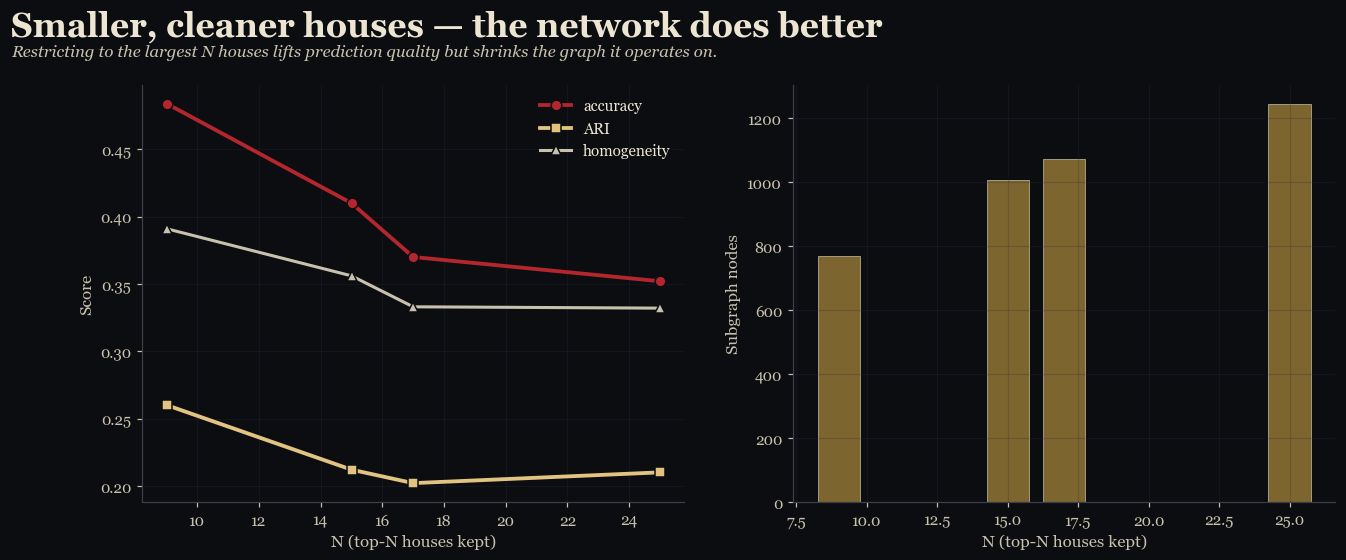

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))
ns = list(l2_df.index)

axes[0].plot(ns, l2_df['accuracy'], 'o-',
             color=PALETTE['crimson_bright'], linewidth=2.5,
             markeredgecolor=PALETTE['bg'], markersize=7,
             label='accuracy')
axes[0].plot(ns, l2_df['ARI'], 's-',
             color=PALETTE['gold_bright'], linewidth=2.5,
             markeredgecolor=PALETTE['bg'], markersize=6,
             label='ARI')
axes[0].plot(ns, l2_df['homogeneity'], '^-',
             color=PALETTE['ink_soft'], linewidth=2,
             markeredgecolor=PALETTE['bg'], markersize=6,
             label='homogeneity')
axes[0].set_xlabel('N (top-N houses kept)')
axes[0].set_ylabel('Score')
axes[0].grid(alpha=0.25, color=PALETTE['line'])
axes[0].legend(loc='best', fontsize=10)

axes[1].bar(ns, l2_df['subgraph_nodes'], width=1.5,
            color=PALETTE['gold_deep'], edgecolor=PALETTE['ink'],
            linewidth=0.4, alpha=0.9)
axes[1].set_xlabel('N (top-N houses kept)')
axes[1].set_ylabel('Subgraph nodes')
axes[1].grid(alpha=0.25, color=PALETTE['line'])

fig.subplots_adjust(top=0.84)
got_title(fig,
          'Smaller, cleaner houses — the network does better',
          'Restricting to the largest N houses lifts prediction quality but shrinks the graph it operates on.')

save_fig(fig, 'figures/level2_sweep.png')
plt.show()


## 5. Level 3 — Top-K houses per canonical region (stratified)

We take the top-K houses *per* canonical Westeros region (not globally), so every region is represented. With K=3 across 9 canonical regions we get up to 27 houses — a stratified main-actor set that doesn't let Westerlands or Reach swamp Iron Islands or Dorne by raw character count.

Region is used only as a **stratification axis**; the prediction target is still house. This is the *fair-but-hard* counterpart to Level 2: balanced across the realm, but with 27 labels competing for ~10 communities.

In [34]:
K = 3
stratified_houses = set()
for region in CANONICAL_REGIONS:
    region_houses = REGION_TO_HOUSES[region]
    members = Counter(primary_house[v] for v in LCC.nodes()
                     if primary_house.get(v) in region_houses)
    top_k = [h for h, _ in members.most_common(K) if members[h] > 0]
    stratified_houses.update(top_k)
    print(f'  {region:15s} top-{K}: {[h for h in top_k]}')
print(f'\nTotal stratified house set: {len(stratified_houses)} houses')

keep = {v for v in LCC.nodes() if primary_house.get(v) in stratified_houses}
sub_l3 = LCC.subgraph(keep).copy()
sub_l3 = sub_l3.subgraph(max(nx.connected_components(sub_l3), key=len)).copy()
p_l3, Q_l3, k_l3 = louvain_partition(sub_l3)
labels_l3 = {v: primary_house[v] for v in sub_l3.nodes()}

result_l3 = evaluate(p_l3, labels_l3, name=f'L3: top-{K} per region')
result_l3['subgraph_nodes'] = sub_l3.number_of_nodes()
result_l3['subgraph_edges'] = sub_l3.number_of_edges()
result_l3['modularity'] = Q_l3
result_l3

  North           top-3: ['House_Stark', 'House_Manderly', 'House_Bolton']
  Iron_Islands    top-3: ['House_Greyjoy', 'House_Botley', 'House_Hoare']
  Riverlands      top-3: ['House_Frey', 'House_Tully', 'House_Bracken']
  Vale            top-3: ['House_Arryn', 'House_Royce', 'House_Baelish']
  Westerlands     top-3: ['House_Lannister', 'House_Clegane', 'House_Farman']
  Reach           top-3: ['House_Tyrell', 'House_Hightower', 'House_Osgrey']
  Stormlands      top-3: ['House_Baratheon', 'House_Swann', 'House_Connington']
  Dorne           top-3: ['House_Martell', 'House_Dayne', 'House_Yronwood']
  Crownlands      top-3: ['House_Targaryen', 'House_Velaryon', 'Blacks']

Total stratified house set: 27 houses


{'level': 'L3: top-3 per region',
 'n_nodes_scored': 923,
 'n_communities': 10,
 'n_labels': 27,
 'accuracy': 0.323943661971831,
 'ARI': 0.11060745506142985,
 'homogeneity': 0.2585662884851384,
 'completeness': 0.41969882790568414,
 'subgraph_nodes': 923,
 'subgraph_edges': 5350,
 'modularity': 0.6047215652022011}

## 6. Cross-level comparison

Bringing all three levels onto one chart so we can compare prediction quality apples-to-apples.

The label spaces differ across levels (different |labels|), so accuracy alone isn't strictly comparable — a 9-house task is mechanically easier than a 265-house task. ARI is chance-adjusted and *is* directly comparable across label spaces — that's the column to read for the headline answer.

In [35]:
# Pick the most informative Level 2 result for the comparison (best accuracy)
best_l2 = max(L2_RESULTS, key=lambda r: r['accuracy'])

summary = pd.DataFrame([
    result_l1,
    {**best_l2, 'level': f"L2: top-{best_l2['N']} houses (best)"},
    result_l3,
])[['level', 'n_nodes_scored', 'n_labels', 'n_communities',
    'accuracy', 'ARI', 'homogeneity', 'completeness']].round(3)
print(summary.to_string(index=False))

                  level  n_nodes_scored  n_labels  n_communities  accuracy   ARI  homogeneity  completeness
         L1: all houses            2392       265             13     0.188 0.076        0.254         0.541
L2: top-9 houses (best)             769         9              8     0.484 0.260        0.391         0.433
   L3: top-3 per region             923        27             10     0.324 0.111        0.259         0.420


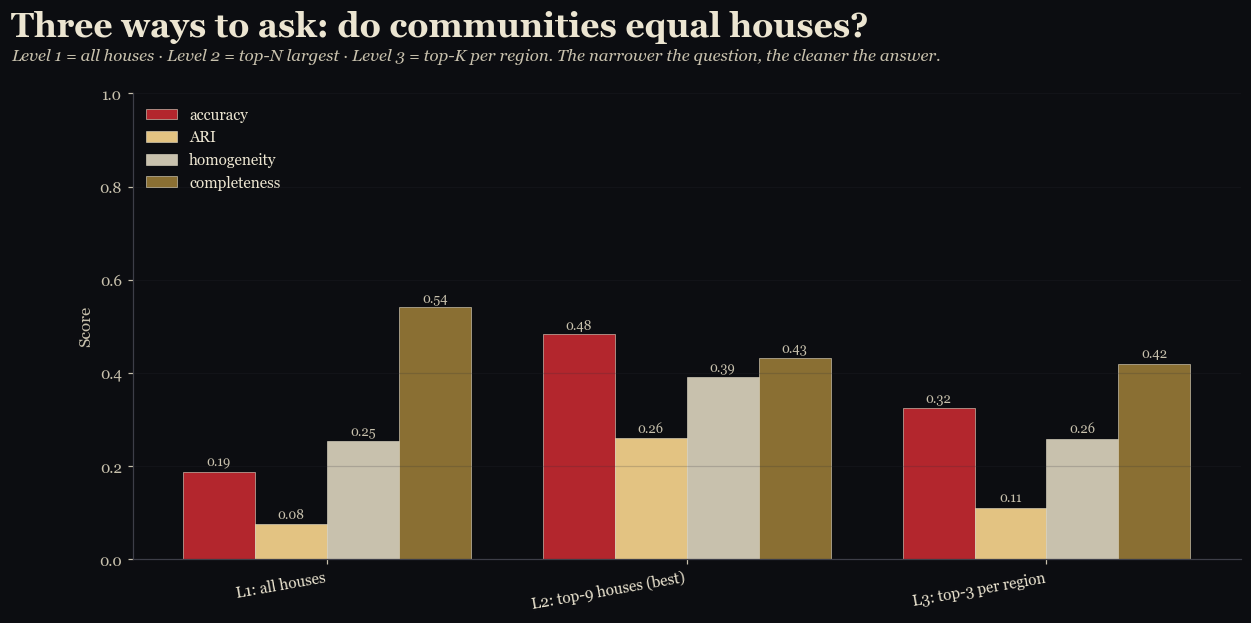

In [36]:
fig, ax = plt.subplots(figsize=(13, 5.8))
levels = summary['level'].tolist()
metrics = ['accuracy', 'ARI', 'homogeneity', 'completeness']
metric_colors = [
    PALETTE['crimson_bright'],
    PALETTE['gold_bright'],
    PALETTE['ink_soft'],
    PALETTE['gold_deep'],
]
x = np.arange(len(levels))
w = 0.2

for i, m in enumerate(metrics):
    offsets = (i - 1.5) * w
    bars = ax.bar(x + offsets, summary[m], w,
                  label=m, color=metric_colors[i],
                  edgecolor=PALETTE['ink'], linewidth=0.35)
    for b, v in zip(bars, summary[m]):
        ax.text(b.get_x() + b.get_width() / 2, v + 0.012, f'{v:.2f}',
                ha='center', fontsize=8.5, color=PALETTE['ink_soft'],
                family='serif')

ax.set_xticks(x)
ax.set_xticklabels(levels, rotation=10, ha='right', color=PALETTE['ink'])
ax.set_ylabel('Score')
ax.legend(loc='upper left', fontsize=10)
ax.set_ylim(0, max(summary[metrics].values.max() + 0.12, 1.0))
ax.grid(alpha=0.2, axis='y', color=PALETTE['line'])

fig.subplots_adjust(top=0.84)
got_title(fig,
          'Three ways to ask: do communities equal houses?',
          'Level 1 = all houses · Level 2 = top-N largest · Level 3 = top-K per region. The narrower the question, the cleaner the answer.')

save_fig(fig, 'figures/levels_comparison.png')
plt.show()


## 7. Westeros map: nodes coloured by Louvain community

The full-LCC partition (used in Level 1), placed on a schematic Westeros map so the *physical* region is the spatial axis and the *Louvain community* is the colour. Where colour respects geography, communities are tracking region; where colours splatter across the map, they're tracking something else (dynasty, plot, era).

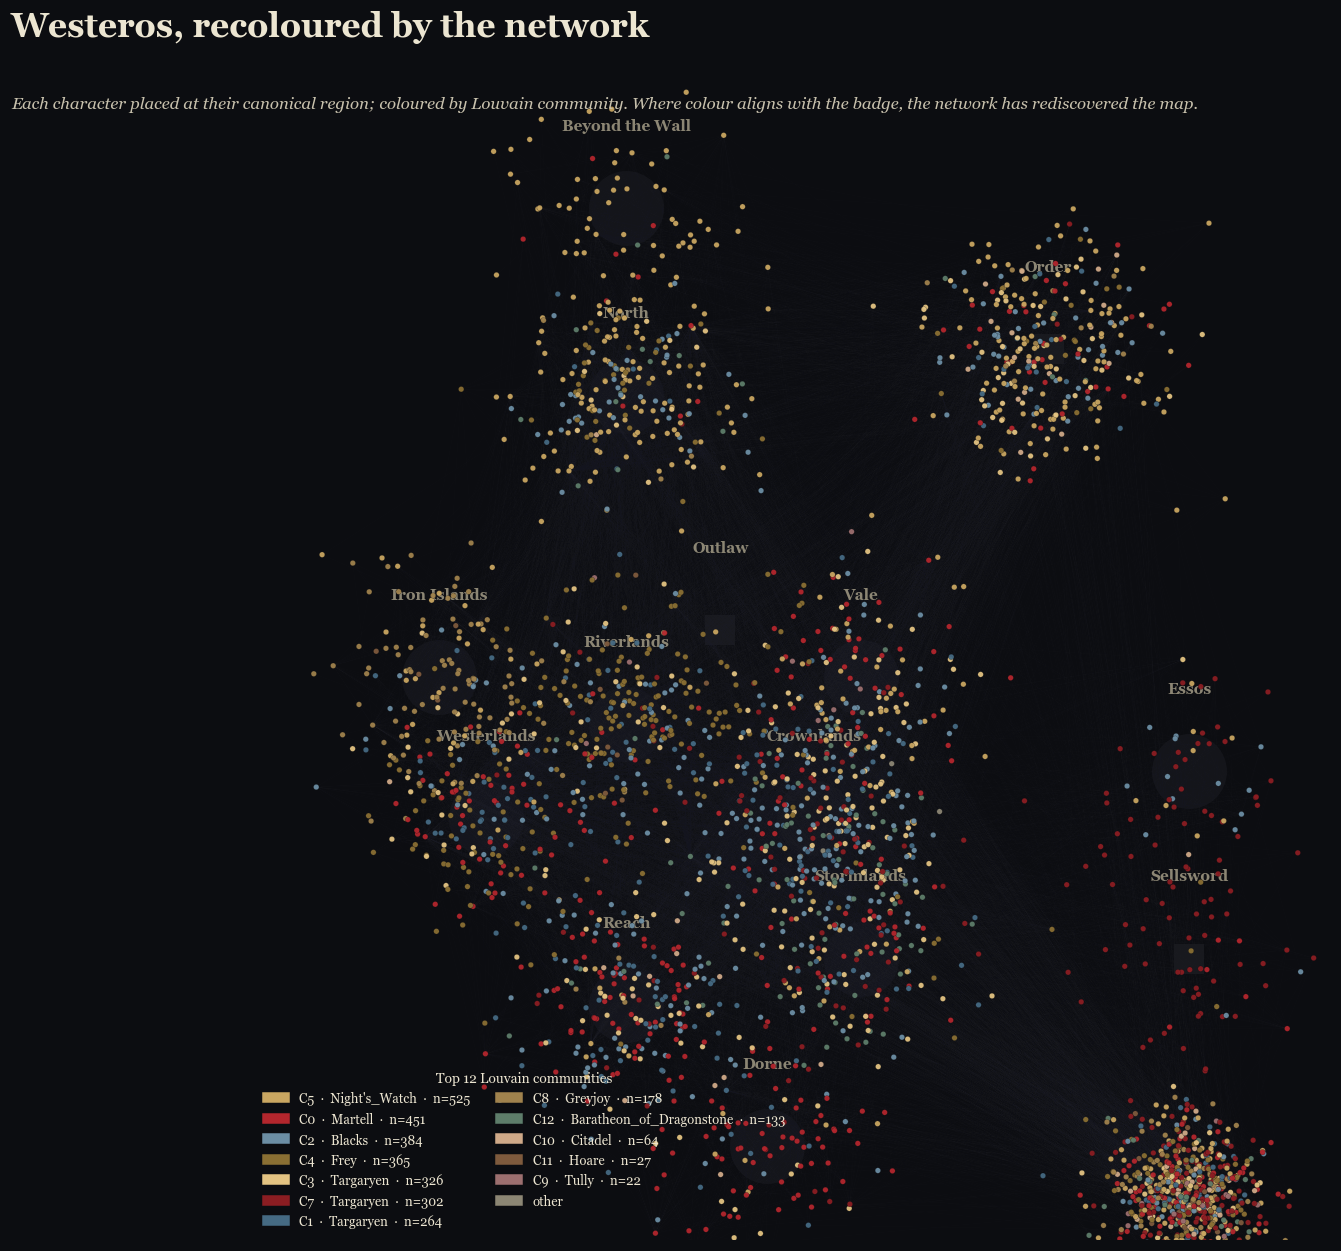

In [37]:
REGION_XY = {
    'North':           (35, 90),
    'Iron_Islands':    (15, 60),
    'Riverlands':      (35, 55),
    'Vale':            (60, 60),
    'Westerlands':     (20, 45),
    'Reach':           (35, 25),
    'Stormlands':      (60, 30),
    'Crownlands':      (55, 45),
    'Dorne':           (50, 10),
    'Beyond_the_Wall': (35, 110),
    'Essos':           (95, 50),
    'Order':           (80, 95),
    'Sellsword':       (95, 30),
    'Outlaw':          (45, 65),
}

# Position every LCC node near its primary_region centroid (jittered).
rng = np.random.default_rng(0)
JITTER = 6.0
pos = {}
for n in LCC.nodes():
    r = primary_region.get(n, '')
    if r in REGION_XY:
        cx, cy = REGION_XY[r]
        pos[n] = (cx + rng.normal(0, JITTER), cy + rng.normal(0, JITTER))
    else:
        pos[n] = (95 + rng.normal(0, 4), 5 + rng.normal(0, 4))

# Top communities get GOT-categorical colors; the rest go muted.
TOP_C = 12
sizes = Counter(partition_full.values())
top_comms = [c for c, _ in sizes.most_common(TOP_C)]
palette = categorical_colors(TOP_C)
comm_color = {c: palette[i] for i, c in enumerate(top_comms)}
OTHER = PALETTE['muted']

fig, ax = plt.subplots(figsize=(15, 13))

# Region badges (faint grey scaffolding so colour can shine on top)
for r, (cx, cy) in REGION_XY.items():
    if r in {'Order', 'Sellsword', 'Outlaw'}:
        ax.scatter([cx], [cy], s=400, color=PALETTE['line_strong'],
                   alpha=0.25, marker='s', linewidths=0)
    else:
        ax.scatter([cx], [cy], s=2400, color=PALETTE['line_strong'],
                   alpha=0.18, marker='o', linewidths=0)
    ax.text(cx, cy + 8, r.replace('_', ' '), ha='center', va='bottom',
            fontsize=10, fontweight='bold', color=PALETTE['muted'],
            family='serif')

# Edges
for u, v in LCC.edges():
    x1, y1 = pos[u]; x2, y2 = pos[v]
    ax.plot([x1, x2], [y1, y2], color=PALETTE['line_strong'],
            alpha=0.05, linewidth=0.3, zorder=1)

# Nodes
node_c = [comm_color.get(partition_full[n], OTHER) for n in LCC.nodes()]
ax.scatter([pos[n][0] for n in LCC.nodes()],
           [pos[n][1] for n in LCC.nodes()],
           c=node_c, s=13, alpha=0.95, linewidths=0.15,
           edgecolors=PALETTE['bg'], zorder=3)

# Legend with dominant house per community
top_legend = []
for c in top_comms:
    members = [n for n in LCC.nodes()
               if partition_full[n] == c and primary_house.get(n) in HOUSE_TO_REGION]
    dom = Counter(primary_house[m] for m in members).most_common(1)
    dom_name = dom[0][0].replace('House_', '') if dom else '?'
    top_legend.append(mpatches.Patch(
        color=comm_color[c],
        label=f'C{c}  ·  {dom_name}  ·  n={sizes[c]}'))
top_legend.append(mpatches.Patch(color=OTHER, label='other'))
ax.legend(handles=top_legend, loc='lower left', fontsize=8.5, ncol=2,
          labelcolor=PALETTE['ink'],
          facecolor=PALETTE['bg_alt'], edgecolor=PALETTE['line'],
          title=f'Top {TOP_C} Louvain communities',
          title_fontsize=9)

ax.set_xlim(-5, 110); ax.set_ylim(0, 125)
ax.set_aspect('equal'); ax.axis('off')

fig.subplots_adjust(top=0.93)
got_title(fig,
          'Westeros, recoloured by the network',
          'Each character placed at their canonical region; coloured by Louvain community. Where colour aligns with the badge, the network has rediscovered the map.')

save_fig(fig, 'figures/westeros_predict_house.png')
plt.show()


## 8. Conclusions

**Headline answer to the research question:** *Can we predict a character's house from their Louvain community?* — **Only weakly, and only after aggressive filtering.** Stripped down to the 9 biggest houses, ~half of main-actor characters are correctly assigned by their community's dominant label. Across the long tail or across a region-balanced set of 27 houses, accuracy collapses back toward 1-in-3 or worse.

### Per-level results (seed-42 run on `characters_enriched_v3.csv`)

| Level | Setting | Scored | Labels | Accuracy | ARI | Verdict |
|---|---|---|---|---|---|---|
| **1** | All houses, full LCC | 2,392 | 265 | **0.19** | 0.08 | Hard. 13 communities cannot resolve 265 houses; long-tail noise dominates. |
| **2** | Top-N houses (best N=9) | 769 | 9 | **0.48** | 0.26 | The clearest "main actors" picture. Strip the long tail and Louvain pulls house signal *out of* regional signal, but only halfway. |
| **3** | Top-3 houses per region (stratified, 27 houses) | 923 | 27 | **0.32** | 0.11 | Strictest test. Balancing the realm region-by-region drops Louvain back to L1-tier ARI. |

### Reading the L2 sweep (N ∈ {9, 15, 17, 25})

Accuracy **monotonically declines** as N grows: 0.48 → 0.41 → 0.37 → 0.35. There is no peak — every additional house past the 9 largest dilutes the prediction because the new houses are smaller and harder to distinguish from their regional neighbours. ARI behaves similarly, hovering in the 0.20–0.26 band across the sweep.

### Comparing the levels honestly

* **Accuracy alone is misleading across levels** — a 9-house task is mechanically easier than a 265-house task. Read the **ARI** column for chance-adjusted comparison.
* By ARI, **Level 2 (top-9) wins** at 0.26, with **Level 3 (stratified)** at 0.11 and **Level 1** at 0.08. Level 2 wins because we let Louvain only see "main actors" — no minor houses, no Unknowns, no cross-era references diluting the signal.
* Level 3 is the most defensible *fair* comparison (every region is represented, no Westerlands/Reach overrepresentation by raw count). It barely outperforms the full-graph baseline, which is the most honest framing of how well co-mention Louvain identifies *individual* houses.

### What the map (§7) shows

Each Louvain community lands roughly inside one regional badge — colour clusters respect geography. Specifically:

* **The North community** (dominant: Stark) and the **Iron Islands community** (Greyjoy) are the most geographically clean — small, dense, regional.
* **The Riverlands community** (Frey) sits cleanly in the riverlands badge.
* **The Crownlands community** (red) is *bigger than its region* — it's a Targaryen-dynasty-across-300-years cluster, not a King's Landing-area cluster.
* **The Order community** (grey) absorbs Citadel maesters and Night's Watch sworn brothers spanning centuries — a temporal blob, not a geographic one.

### Where prediction succeeds vs. fails

**Succeeds:**

* The dominant house of each canonical region (Stark/Lannister/Tyrell/Tully/Greyjoy/Martell/Targaryen) tends to be the dominant label of one community.
* For the 9 biggest houses, almost half of characters get the right house from community membership alone — well above the ~11% chance baseline.

**Fails:**

* **Same-region minor houses get absorbed by their regional dominant.** Bolton members fall into the Stark community; Reyne falls into the Lannister community. The *region* is recoverable but the *house* prediction collapses to the regional dominant. This is exactly why Level 1 is unsalvageable (~19%) and why Level 3 doesn't rescue it — the moment minor houses re-enter, they're swallowed.
* **Cross-era pulling** — non-Westerosi or off-period characters get sucked into the Targaryen-dynasty community via Daenerys / older Targaryen kings.

### Caveats

1. **Co-mentions are unsigned** — enemies are linked as densely as allies. Two warring houses in the same region (Stark/Bolton, Lannister/Reyne) end up in the same community because their bios cross-reference each other constantly.
2. **Temporal smear** — the wiki collapses ~5,000 years of fictional history into a static graph. Cross-era genealogy edges inflate dynasty communities. A future iteration would scrape `Born` / `Died` and drop edges where active eras don't overlap.
3. **Family-inferred labels are blood, not politics.** Defectors raised away from their birth house are mislabelled — rare in the high-degree set, but a known limitation of §1's Layer 1.
4. **Louvain γ matters.** Default γ=1.0 produces 13 communities here; sweeping (`community_vs_region.ipynb §4.5`) showed the qualitative conclusion is robust across γ ∈ [1.0, 2.0].

### One-line verdict

> Louvain communities are **not house-detectors at full scale** (~19% accuracy on 265 houses) and only **partial house-detectors for the main actors** (~48% on the 9 biggest). What they actually pick out is *region-with-dynasty-overflow* — exactly what you'd expect from a co-mention network of feudal politics with 300 years of inherited references.